In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
DATA_DIR = Path("../data/raw/mask_classification")

classes = [
    "mask",
    "no_mask",
    "improper_mask"
]

print("Dataset:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

for class_name in classes:
    class_dir = DATA_DIR / class_name
    print(
        f"{class_name}: "
        f"{class_dir.exists()}"
    )

Dataset: ..\data\raw\mask_classification
Exists: True
mask: True
no_mask: True
improper_mask: True


In [3]:
class_counts = {}

for class_name in classes:

    class_dir = DATA_DIR / class_name

    images = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    class_counts[class_name] = len(images)

class_counts

{'mask': 3232, 'no_mask': 717, 'improper_mask': 123}

In [4]:
total_images = sum(class_counts.values())

print("Total images:", total_images)

Total images: 4072


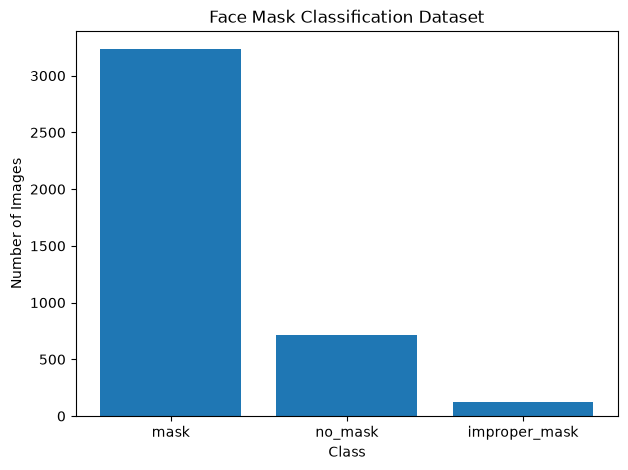

In [5]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Face Mask Classification Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [6]:
class_percentages = {
    class_name: (count / total_images) * 100
    for class_name, count in class_counts.items()
}

for class_name, percentage in class_percentages.items():
    print(
        f"{class_name}: "
        f"{percentage:.2f}%"
    )

mask: 79.37%
no_mask: 17.61%
improper_mask: 3.02%


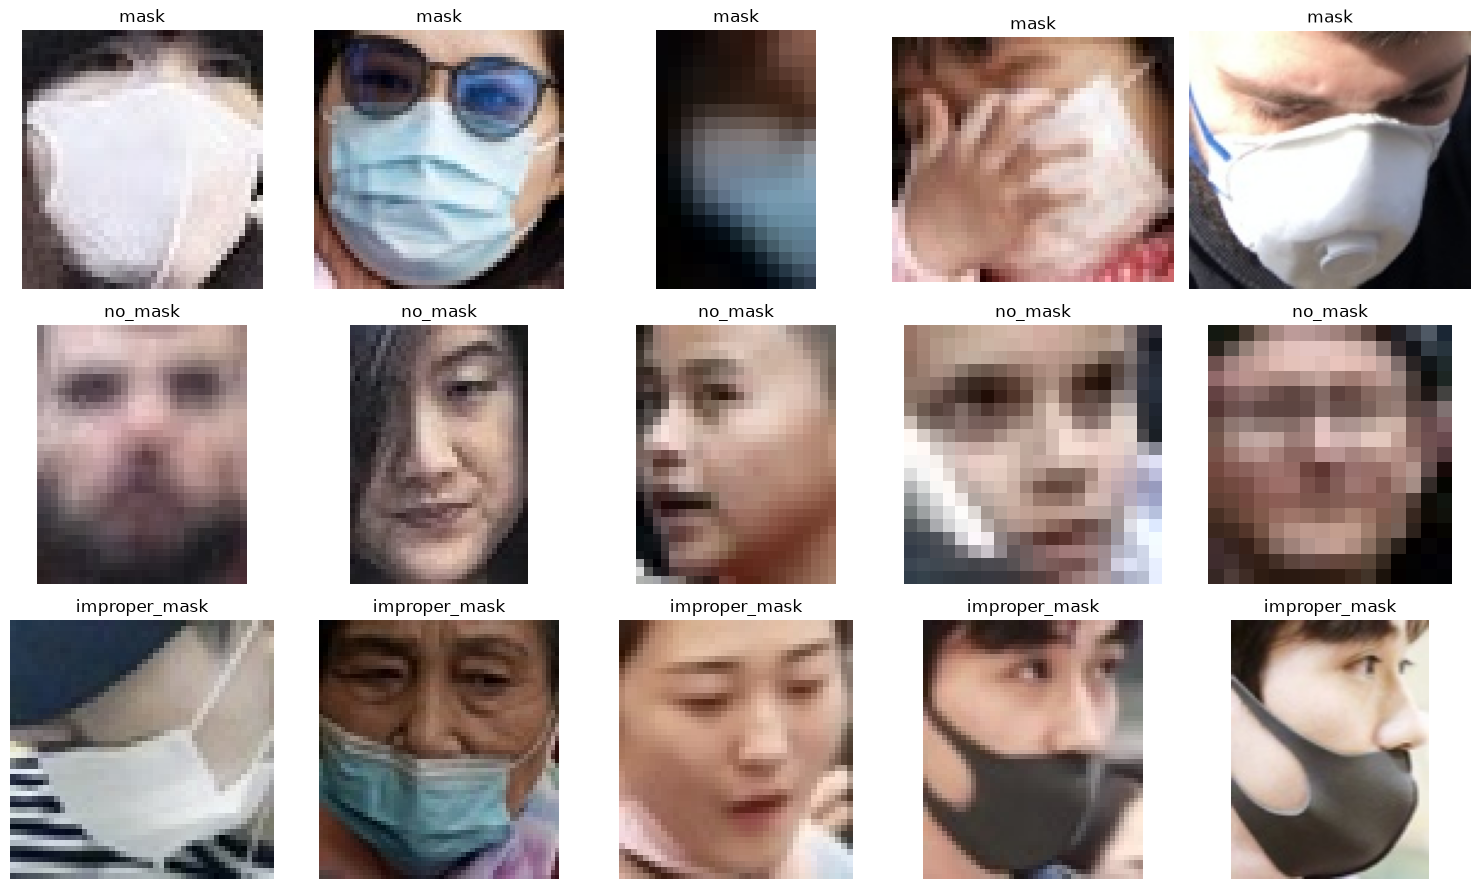

In [7]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 9)
)

for row, class_name in enumerate(classes):

    class_dir = DATA_DIR / class_name

    images = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    samples = images[:5]

    for col, image_path in enumerate(samples):

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
image_info = []

for class_name in classes:

    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        try:

            image = Image.open(image_path)

            width, height = image.size

            image_info.append({
                "class": class_name,
                "width": width,
                "height": height,
                "channels": len(image.getbands())
            })

        except Exception:
            pass

df = pd.DataFrame(image_info)

df.head()

,class,width,height,channels
0,mask,41,44,3
1,mask,56,58,3
2,mask,13,21,3
3,mask,45,39,3
4,mask,116,106,3


In [13]:
df['class'].count()

np.int64(4072)

In [9]:
df.describe()

,width,height,channels
count,4072.000000,4072.000000,4072.0
mean,31.146120,35.004912,3.0
std,27.960328,32.635004,0.0
min,1.000000,2.000000,3.0
25%,14.000000,16.000000,3.0
50%,22.000000,24.000000,3.0
75%,36.000000,40.000000,3.0
max,317.000000,340.000000,3.0


In [10]:
corrupted = []

for class_name in classes:

    class_dir = DATA_DIR / class_name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        try:

            image = Image.open(image_path)

            image.verify()

        except Exception:

            corrupted.append(
                str(image_path)
            )

print(
    "Corrupted images:",
    len(corrupted)
)

Corrupted images: 0


In [11]:
df["area"] = df["width"] * df["height"]

print(
    df.sort_values("area").head(20)
)

        class  width  height  channels  area
2330     mask      1       2         3     2
2327     mask      1       2         3     2
2323     mask      1       2         3     2
2328     mask      2       2         3     4
3796  no_mask      2       3         3     6
2329     mask      2       3         3     6
2326     mask      3       3         3     9
1561     mask      4       3         3    12
2119     mask      5       3         3    15
176      mask      4       4         3    16
2325     mask      3       6         3    18
2123     mask      4       5         3    20
3751  no_mask      4       5         3    20
1024     mask      4       5         3    20
721      mask      4       5         3    20
2095     mask      4       5         3    20
722      mask      4       5         3    20
2751     mask      4       5         3    20
3750  no_mask      4       6         3    24
1030     mask      4       6         3    24


In [12]:
print(
    "Smallest image:",
    df["area"].min()
)

print(
    "Largest image:",
    df["area"].max()
)

Smallest image: 2
Largest image: 106829


{'mask': 2237, 'no_mask': 462, 'improper_mask': 84}


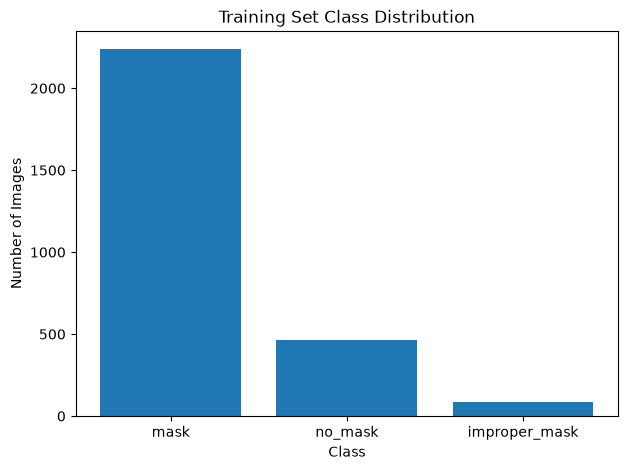

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt

TRAIN_DIR = Path("../data/processed/mask_classification/train")

train_counts = {}

for class_name in ["mask", "no_mask", "improper_mask"]:
    train_counts[class_name] = len(
        list((TRAIN_DIR / class_name).glob("*"))
    )

print(train_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()